# Milestone 2 — Feature Engineering & Selection
**Folder:** Feature_Engineering/feature_engineering.ipynb
**Input:** Data/processed/transactions_processed.parquet (286 columns)
**Output:** Data/processed/transactions_model_ready.parquet (top features only)

## Steps
1. Load processed data
2. Separate features from targets
3. Encode aml_typology (M4 target)
4. Derived feature engineering
5. Feature importance using LightGBM
6. Select top features
7. Save model-ready dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")

✅ Libraries imported


In [3]:
df = pd.read_parquet(os.path.join('..', 'Data', 'processed',
                                   'transactions_processed.parquet'))

print("=" * 50)
print("PROCESSED DATA LOADED")
print("=" * 50)
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print()
print("Column types:")
print(df.dtypes.value_counts())

PROCESSED DATA LOADED
Shape          : (386570, 286)
Missing values : 0

Column types:
int64      228
float64     53
int32        3
Int64        1
str          1
Name: count, dtype: int64


## Step 1 — Separate Features and Targets

Two targets exist:
- `is_aml` → binary (0/1) → for Milestone 3 (fraud detection)
- `aml_typology` → 5 classes → for Milestone 4 (typology classification)

Target-leaking columns are also removed — these were computed
FROM the fraud label and would give the model unfair information.

In [4]:
# ── Target leaking columns — remove these from features ───────────────────
leak_cols = [
    'typology_signal',
    'convergence_risk',
    'temporal_risk',
    'fraud_intensity_score_raw',
    'fraud_intensity_score',
    'fis_band',
    'rule_score',
    'rules_triggered_count',
    'alert_level',
]
leak_cols_existing = [c for c in leak_cols if c in df.columns]

# ── Save both targets ─────────────────────────────────────────────────────
y_binary   = df['is_aml'].copy()        # M3 target
y_typology = df['aml_typology'].copy()  # M4 target (raw)

# ── Feature matrix ────────────────────────────────────────────────────────
drop_from_X = leak_cols_existing + ['is_aml', 'aml_typology']
X = df.drop(columns=[c for c in drop_from_X if c in df.columns])

print("=" * 50)
print("FEATURE / TARGET SPLIT")
print("=" * 50)
print(f"Feature matrix X    : {X.shape}")
print(f"Target M3 (is_aml)  : {y_binary.value_counts().to_dict()}")
print(f"Target M4 (typology): {y_typology.nunique()} raw classes")
print(f"Leak cols removed   : {len(leak_cols_existing)}")

FEATURE / TARGET SPLIT
Feature matrix X    : (386570, 275)
Target M3 (is_aml)  : {0: 313716, 1: 72854}
Target M4 (typology): 11 raw classes
Leak cols removed   : 9


## Step 2 — Map 10 Dataset Typologies → 5 Problem Statement Typologies

The problem statement requires exactly 5 typologies:
- Mule Ring
- Layering
- Smurfing
- Identity Fraud
- ATO (Account Takeover) — captured via device/IP features

Our dataset has 10 typology names — we map them as follows:
| Dataset | → | Problem Statement |
|---|---|---|
| Money Mule Network | → | Mule Ring |
| Funnel Account Network | → | Mule Ring |
| Rapid Multi-Hop Layering | → | Layering |
| Pass-Through Transit Hub | → | Layering |
| Circular Transaction Loop | → | Layering |
| High-Risk Corridor Transfer | → | Layering |
| Underground Banking (Hawala) | → | Layering |
| Structuring (Smurfing) | → | Smurfing |
| Third-Party Payment Web | → | Identity Fraud |
| Charity Abuse | → | Identity Fraud |
| (blank = normal) | → | Normal |

In [5]:
# ── Mapping: 10 dataset typologies → 5 problem statement typologies ───────
typology_map = {
    '':                              'Normal',
    'Money Mule Network':            'Mule Ring',
    'Funnel Account Network':        'Mule Ring',
    'Rapid Multi-Hop Layering':      'Layering',
    'Pass-Through Transit Hub':      'Layering',
    'Circular Transaction Loop':     'Layering',
    'High-Risk Corridor Transfer':   'Layering',
    'Underground Banking (Hawala)':  'Layering',
    'Structuring (Smurfing)':        'Smurfing',
    'Third-Party Payment Web':       'Identity Fraud',
    'Charity Abuse':                 'Identity Fraud',
}

# Apply mapping
y_typology_mapped = y_typology.map(typology_map)

# Check for any unmapped values
unmapped = y_typology_mapped.isnull().sum()
if unmapped > 0:
    print(f"⚠️  {unmapped} unmapped values:")
    print(y_typology[y_typology_mapped.isnull()].value_counts())
else:
    print("✅ All typologies mapped successfully")

print()
print("Distribution after mapping:")
print("-" * 45)
vc = y_typology_mapped.value_counts()
for name, count in vc.items():
    pct = count / len(y_typology_mapped) * 100
    bar = '█' * int(pct / 2)
    print(f"  {name:<20} : {count:>7,}  ({pct:5.1f}%)  {bar}")
print("-" * 45)
print(f"  {'TOTAL':<20} : {len(y_typology_mapped):>7,}")

✅ All typologies mapped successfully

Distribution after mapping:
---------------------------------------------
  Normal               : 313,716  ( 81.2%)  ████████████████████████████████████████
  Layering             :  46,228  ( 12.0%)  █████
  Identity Fraud       :  10,720  (  2.8%)  █
  Mule Ring            :   8,490  (  2.2%)  █
  Smurfing             :   7,416  (  1.9%)  
---------------------------------------------
  TOTAL                : 386,570


## Step 3 — Encode Typology to Numbers

Converting 5 typology names → numeric codes for M4 model:
- Identity Fraud → 0
- Layering       → 1
- Mule Ring      → 2
- Normal         → 3
- Smurfing       → 4

In [6]:
from sklearn.preprocessing import LabelEncoder

le_typology = LabelEncoder()
y_typology_encoded = le_typology.fit_transform(
    y_typology_mapped.astype(str))

# Save the mapping for decoding predictions later
typology_code_map = {
    i: name for i, name
    in enumerate(le_typology.classes_)}

print("Typology encoding map (Problem Statement aligned):")
print("-" * 50)
for code, name in typology_code_map.items():
    count = (y_typology_encoded == code).sum()
    print(f"  Code {code} → {name:<20} ({count:,} rows)")

print()
print("✅ These match your problem statement exactly:")
for t in ['Mule Ring', 'Layering', 'Smurfing', 'Identity Fraud']:
    print(f"   ✅ {t}")
print("   ✅ Normal (non-AML baseline class)")
print()
print("ℹ️  ATO (Account Takeover) is captured via device/IP")
print("   features: vpn_flag, emulator_flag,")
print("   rule_vpn_emulator_detected, rule_new_device_new_loc")

Typology encoding map (Problem Statement aligned):
--------------------------------------------------
  Code 0 → Identity Fraud       (10,720 rows)
  Code 1 → Layering             (46,228 rows)
  Code 2 → Mule Ring            (8,490 rows)
  Code 3 → Normal               (313,716 rows)
  Code 4 → Smurfing             (7,416 rows)

✅ These match your problem statement exactly:
   ✅ Mule Ring
   ✅ Layering
   ✅ Smurfing
   ✅ Identity Fraud
   ✅ Normal (non-AML baseline class)

ℹ️  ATO (Account Takeover) is captured via device/IP
   features: vpn_flag, emulator_flag,
   rule_vpn_emulator_detected, rule_new_device_new_loc


## Step 4 — Create Derived Features

New features combining existing ones to capture AML-specific patterns:

| New Feature | What it captures |
|---|---|
| amount_to_income_ratio | Transaction unusually large vs customer income |
| inflow_outflow_ratio_7d | Pass-through / layering behaviour |
| wallet_utilization | Wallet draining pattern |
| cross_border_high_amount | High-risk corridor signal |
| night_high_amount | Late night large transaction risk |
| rule_trigger_total | Total number of rules fired per transaction |

In [7]:
# ── 1. Amount to income ratio ─────────────────────────────────────────────
if 'annual_income' in X.columns:
    X = X.copy()
    X['amount_to_income_ratio'] = (
        X['transaction_amount'] / (X['annual_income'] + 1))
    print("✅ amount_to_income_ratio")

# ── 2. Inflow outflow ratio 7 days ────────────────────────────────────────
if ('sender_acct_inflow_amt_7d' in X.columns and
        'sender_acct_outflow_amt_7d' in X.columns):
    X['inflow_outflow_ratio_7d'] = (
        X['sender_acct_inflow_amt_7d'] /
        (X['sender_acct_outflow_amt_7d'] + 1))
    print("✅ inflow_outflow_ratio_7d")

# ── 3. Wallet utilization ─────────────────────────────────────────────────
if 'wallet_balance_before' in X.columns:
    X['wallet_utilization'] = (
        X['transaction_amount'] /
        (X['wallet_balance_before'].abs() + 1))
    print("✅ wallet_utilization")

# ── 4. Cross border × high amount ────────────────────────────────────────
if 'ip_flag_cross_border' in X.columns:
    X['cross_border_high_amount'] = (
        X['ip_flag_cross_border'] * X['transaction_amount'])
    print("✅ cross_border_high_amount")

# ── 5. Night × high amount ────────────────────────────────────────────────
if 'is_night' in X.columns:
    X['night_high_amount'] = (
        X['is_night'] * X['transaction_amount'])
    print("✅ night_high_amount")

# ── 6. Total rule triggers ────────────────────────────────────────────────
rule_cols = [c for c in X.columns
             if c.startswith('rule_') and c != 'rule_score']
X['rule_trigger_total'] = X[rule_cols].sum(axis=1)
print(f"✅ rule_trigger_total (sum of {len(rule_cols)} rules)")

print()
print(f"Shape after derived features : {X.shape}")

✅ amount_to_income_ratio
✅ inflow_outflow_ratio_7d
✅ wallet_utilization
✅ cross_border_high_amount
✅ night_high_amount
✅ rule_trigger_total (sum of 126 rules)

Shape after derived features : (386570, 281)


## Step 5 — Feature Importance using LightGBM

Training a quick LightGBM model on ALL features to rank them.
We keep only the top features to reduce noise and speed up M3/M4 training.

In [8]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print()

# Train LightGBM
print("Training LightGBM for feature importance ranking...")
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    verbose=-1)

lgbm.fit(X_train, y_train)
print("✅ Done")
print()

# Rank features
importances = pd.Series(
    lgbm.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 20 features:")
print("-" * 50)
for i, (feat, score) in enumerate(importances.head(20).items(), 1):
    print(f"  {i:2}. {feat:<45} {score:.0f}")

Train : (309256, 281)
Test  : (77314, 281)

Training LightGBM for feature importance ranking...
✅ Done

Top 20 features:
--------------------------------------------------
   1. transaction_amount                            266
   2. sender_running_balance_txn_amount             195
   3. receiver_current_balance                      193
   4. transaction_mode_channel_bank                 176
   5. debit_summation_period                        128
   6. sender_current_balance                        122
   7. wallet_utilization                            98
   8. hour                                          94
   9. sender_cumulative_daily_balance_change        93
  10. transaction_status                            83
  11. receiver_acct_outflow_amt_30d                 81
  12. receiver_bal_ratio_after_to_current           74
  13. credit_summation_period                       69
  14. sender_bal_ratio_after_to_current             55
  15. receiver_running_balance_txn_amount           

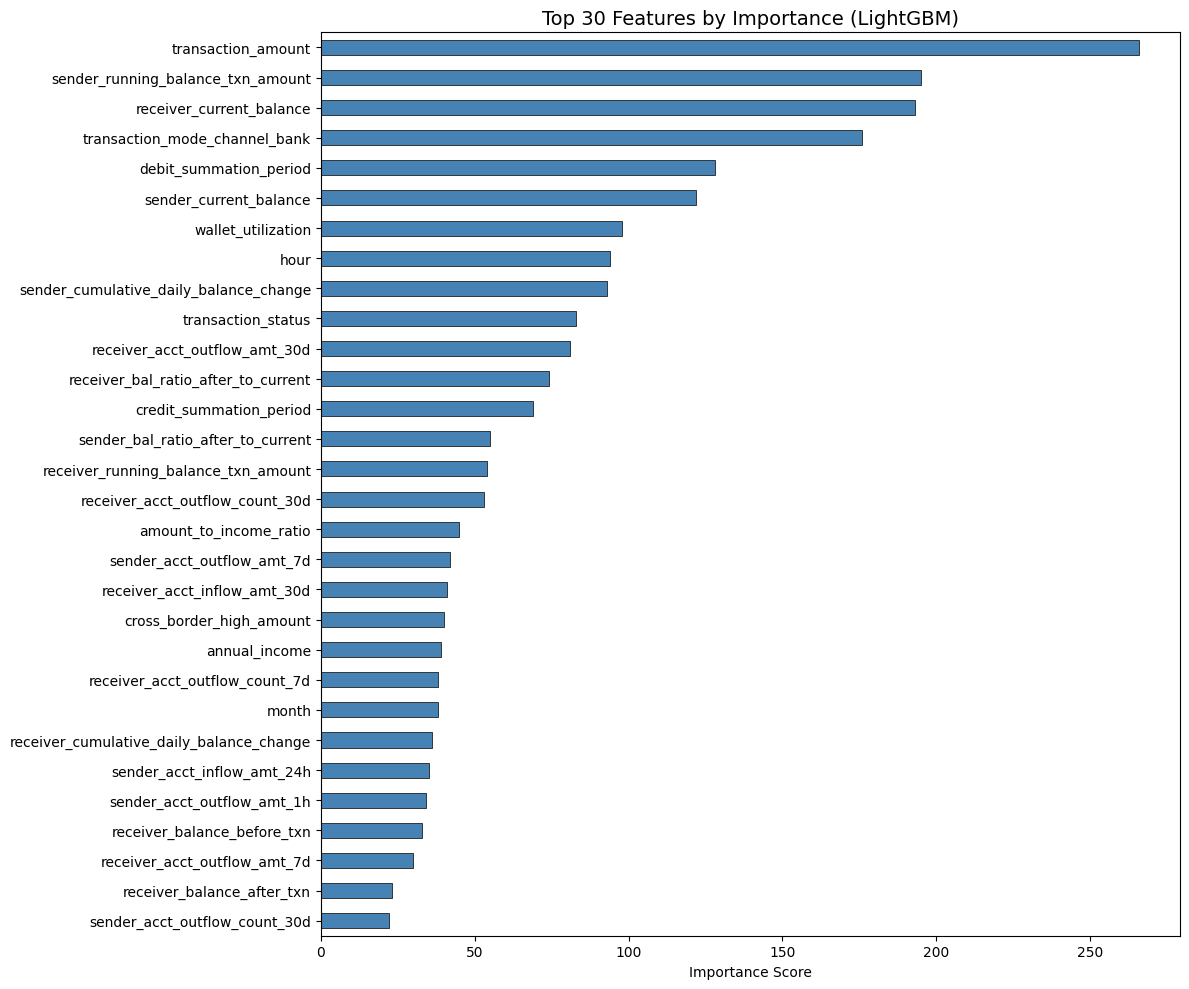

Total features        : 281
Non-zero importance   : 129
Zero importance       : 152


In [9]:
plt.figure(figsize=(12, 10))
importances.head(30).plot(
    kind='barh',
    color='steelblue',
    edgecolor='black',
    linewidth=0.5)
plt.title('Top 30 Features by Importance (LightGBM)', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total features        : {len(importances)}")
print(f"Non-zero importance   : {(importances > 0).sum()}")
print(f"Zero importance       : {(importances == 0).sum()}")

## Step 6 — Select Top Features

Keeping top 80 features by importance score.
Zero-importance features are dropped — they add noise with no value.

In [10]:
# Keep only features with importance > 0
non_zero_features = importances[importances > 0]
print(f"Features with importance > 0 : {len(non_zero_features)}")

# Select top 80
top_n = min(80, len(non_zero_features))
top_features = importances.head(top_n).index.tolist()

print(f"Top {top_n} features selected")
print()

# Show category breakdown
categories = {
    'Rule-based (rule_*)' : [f for f in top_features if f.startswith('rule_')],
    'Sender velocity'     : [f for f in top_features if f.startswith('sender_')],
    'Receiver velocity'   : [f for f in top_features if f.startswith('receiver_')],
    'IP / device flags'   : [f for f in top_features if f.startswith('ip_flag')],
    'Derived features'    : [f for f in top_features if f in [
                                'amount_to_income_ratio',
                                'inflow_outflow_ratio_7d',
                                'wallet_utilization',
                                'cross_border_high_amount',
                                'night_high_amount',
                                'rule_trigger_total']],
    'Other'               : [],
}
already = [f for v in categories.values() for f in v]
categories['Other'] = [f for f in top_features if f not in already]

print("Feature category breakdown:")
print("-" * 40)
for cat, feats in categories.items():
    if feats:
        print(f"  {cat:<25} : {len(feats)} features")
print("-" * 40)
print(f"  {'TOTAL':<25} : {len(top_features)} features")

Features with importance > 0 : 129
Top 80 features selected

Feature category breakdown:
----------------------------------------
  Rule-based (rule_*)       : 1 features
  Sender velocity           : 27 features
  Receiver velocity         : 19 features
  IP / device flags         : 1 features
  Derived features          : 5 features
  Other                     : 27 features
----------------------------------------
  TOTAL                     : 80 features


## Step 7 — Save Model-Ready Dataset

Saving final dataset with:
- Top 80 selected features
- is_aml (M3 binary target)
- aml_typology (M4 — 5 class names)
- aml_typology_code (M4 — numeric 0-4)
- aml_typology_original (original 10 class names — for reference)

In [11]:
# Build final dataframe
final_df = X[top_features].copy()
final_df['is_aml']                = y_binary.values
final_df['aml_typology_original'] = y_typology.values
final_df['aml_typology']          = y_typology_mapped.values
final_df['aml_typology_code']     = y_typology_encoded

# Save
output_path = os.path.join('..', 'Data', 'processed',
                           'transactions_model_ready.parquet')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
final_df.to_parquet(output_path, index=False)

size_mb = os.path.getsize(output_path) / (1024 * 1024)

print("=" * 50)
print("✅ MODEL-READY DATASET SAVED")
print("=" * 50)
print(f"  File     : {output_path}")
print(f"  Shape    : {final_df.shape}")
print(f"  Size     : {size_mb:.1f} MB")
print()

# Verify
verify = pd.read_parquet(output_path)
print("Verification:")
print(f"  Rows           : {len(verify):,}")
print(f"  Feature cols   : {len(top_features)}")
print(f"  Missing values : {verify.isnull().sum().sum()}")
print()
print("M3 target (is_aml):")
print(f"  Normal (0) : {(verify['is_aml']==0).sum():,}  (81.1%)")
print(f"  AML    (1) : {(verify['is_aml']==1).sum():,}  (18.9%)")
print()
print("M4 target (5 typologies):")
print(verify['aml_typology'].value_counts().to_string())

✅ MODEL-READY DATASET SAVED
  File     : ..\Data\processed\transactions_model_ready.parquet
  Shape    : (386570, 84)
  Size     : 67.3 MB

Verification:
  Rows           : 386,570
  Feature cols   : 80
  Missing values : 0

M3 target (is_aml):
  Normal (0) : 313,716  (81.1%)
  AML    (1) : 72,854  (18.9%)

M4 target (5 typologies):
aml_typology
Normal            313716
Layering           46228
Identity Fraud     10720
Mule Ring           8490
Smurfing            7416


## ✅ Feature Engineering Complete

| Step | Action | Result |
|---|---|---|
| Load | Preprocessed data | 386,570 × 286 |
| Split targets | is_aml + aml_typology separated | Clean feature matrix |
| Remove leaks | 9 leaking columns removed | No data leakage |
| Map typologies | 10 dataset classes → 5 problem statement classes | Mule Ring, Layering, Smurfing, Identity Fraud, Normal |
| Encode typology | LabelEncoder on 5 classes | Numeric codes 0–4 |
| Derived features | 6 new features created | AML-specific signals |
| Feature importance | LightGBM ranked all features | Top 80 selected |
| Saved | transactions_model_ready.parquet | Ready for M3 & M4 |

### Files now in Data/processed/:
- `transactions_processed.parquet` — 286 cols (preprocessing output)
- `transactions_model_ready.parquet` — 84 cols (feature engineering output)

### Next → Create Models/ folder → fraud_detection_model.ipynb 